In [1]:
import os
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
from matplotlib import pyplot as plt
from wordcloud import WordCloud, STOPWORDS
import torch
import random

In [2]:
def set_seed(seed=42):
    # Python random
    random.seed(seed)

    # NumPy (used by scikit-learn internally)
    np.random.seed(seed)

    # PyTorch
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # Ensure deterministic behavior in PyTorch
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    # (Optional but recommended for newer PyTorch versions)
    torch.use_deterministic_algorithms(True)

In [3]:
set_seed(42)

In [4]:
train_df = pd.read_csv('/kaggle/input/datasets/pramatharao/nlp-course-project-ds/train-balanced.csv',sep='\t')
train_df.head()

,label,comment,author,subreddit,score,ups,downs,date,created_utc,parent_comment
0,0,NC and NH.,Trumpbart,politics,2,-1,-1,2016-10,1476662123,"Yeah, I get that argument. At this point, I'd ..."
1,0,You do know west teams play against west teams...,Shbshb906,nba,-4,-1,-1,2016-11,1477959850,The blazers and Mavericks (The wests 5 and 6 s...
2,0,"They were underdogs earlier today, but since G...",Creepeth,nfl,3,3,0,2016-09,1474580737,They're favored to win.
3,0,"This meme isn't funny none of the ""new york ni...",icebrotha,BlackPeopleTwitter,-8,-1,-1,2016-10,1476824627,deadass don't kill my buzz
4,0,I could use one of those tools.,cush2push,MaddenUltimateTeam,6,-1,-1,2016-12,1483117213,Yep can confirm I saw the tool they use for th...


In [5]:
pd.read_csv('/kaggle/input/datasets/pramatharao/nlp-course-project-ds/train-balanced.csv',sep='\t')

,label,comment,author,subreddit,score,ups,downs,date,created_utc,parent_comment
0,0,NC and NH.,Trumpbart,politics,2,-1,-1,2016-10,1476662123,"Yeah, I get that argument. At this point, I'd ..."
1,0,You do know west teams play against west teams...,Shbshb906,nba,-4,-1,-1,2016-11,1477959850,The blazers and Mavericks (The wests 5 and 6 s...
2,0,"They were underdogs earlier today, but since G...",Creepeth,nfl,3,3,0,2016-09,1474580737,They're favored to win.
3,0,"This meme isn't funny none of the ""new york ni...",icebrotha,BlackPeopleTwitter,-8,-1,-1,2016-10,1476824627,deadass don't kill my buzz
4,0,I could use one of those tools.,cush2push,MaddenUltimateTeam,6,-1,-1,2016-12,1483117213,Yep can confirm I saw the tool they use for th...
...,...,...,...,...,...,...,...,...,...,...
1010821,1,I'm sure that Iran and N. Korea have the techn...,TwarkMain,reddit.com,2,2,0,2009-04,1240620472,"No one is calling this an engineered pathogen,..."
1010822,1,"whatever you do, don't vote green!",BCHarvey,climate,1,1,0,2009-05,1242340060,In a move typical of their recent do-nothing a...
1010823,1,Perhaps this is an atheist conspiracy to make ...,rebelcommander,atheism,1,1,0,2009-01,1231633377,Screw the Disabled--I've got to get to Church ...
1010824,1,The Slavs got their own country - it is called...,catsi,worldnews,1,1,0,2009-01,1232745169,I've always been unsettled by that. I hear a l...


In [6]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1010826 entries, 0 to 1010825
Data columns (total 10 columns):
 #   Column          Non-Null Count    Dtype 
---  ------          --------------    ----- 
 0   label           1010826 non-null  int64 
 1   comment         1010771 non-null  object
 2   author          1010826 non-null  object
 3   subreddit       1010826 non-null  object
 4   score           1010826 non-null  int64 
 5   ups             1010826 non-null  int64 
 6   downs           1010826 non-null  int64 
 7   date            1010826 non-null  object
 8   created_utc     1010826 non-null  int64 
 9   parent_comment  1010826 non-null  object
dtypes: int64(5), object(5)
memory usage: 77.1+ MB


In [7]:
test_df = pd.read_csv('/kaggle/input/datasets/pramatharao/nlp-course-project-ds/test-balanced.csv',sep='\t')
test_df.head()

,label,comment,author,subreddit,score,ups,downs,date,created_utc,parent_comment
0,0,Actually most of her supporters and sane peopl...,Quinnjester,politics,3,3,0,2016-09,1473569605,Hillary's Surrogotes Told to Blame Media for '...
1,0,They can't survive without an echo chamber whi...,TheGettysburgAddress,The_Donald,13,-1,-1,2016-11,1478788413,Thank God Liberals like to live in concentrate...
2,0,you're pretty cute yourself 1729 total,Sempiternally_free,2007scape,8,-1,-1,2016-11,1478042903,Saw this cutie training his Attack today...
3,0,If you kill me you'll crash the meme market,Catacomb82,AskReddit,2,-1,-1,2016-10,1477412597,If you were locked in a room with 49 other peo...
4,0,I bet he wrote that last message as he was sob...,Dorian-throwaway,niceguys,5,-1,-1,2016-11,1477962278,You're not even that pretty!


In [8]:
train_df.dropna(subset=['comment'], inplace=True)

In [9]:
train_df['label'].value_counts()

label
0    505403
1    505368
Name: count, dtype: int64

In [10]:
train_texts, valid_texts, y_train, y_valid = \
        train_test_split(train_df, train_df['label'], random_state=42)

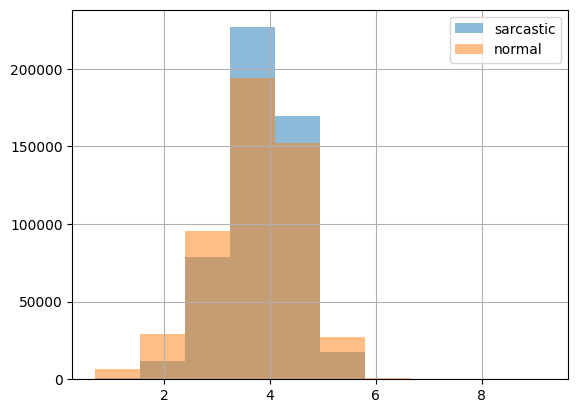

In [11]:
# Distribution of lengths for sarcastic and normal comments is almost the same.

train_df.loc[train_df['label'] == 1, 'comment'].str.len().apply(np.log1p).hist(label='sarcastic', alpha=.5)
train_df.loc[train_df['label'] == 0, 'comment'].str.len().apply(np.log1p).hist(label='normal', alpha=.5)
plt.legend();

In [12]:
# visualise the most common words.
wordcloud = WordCloud(background_color='white', stopwords = STOPWORDS,
                max_words = 200, max_font_size = 100, 
                random_state = 42, width=800, height=400)

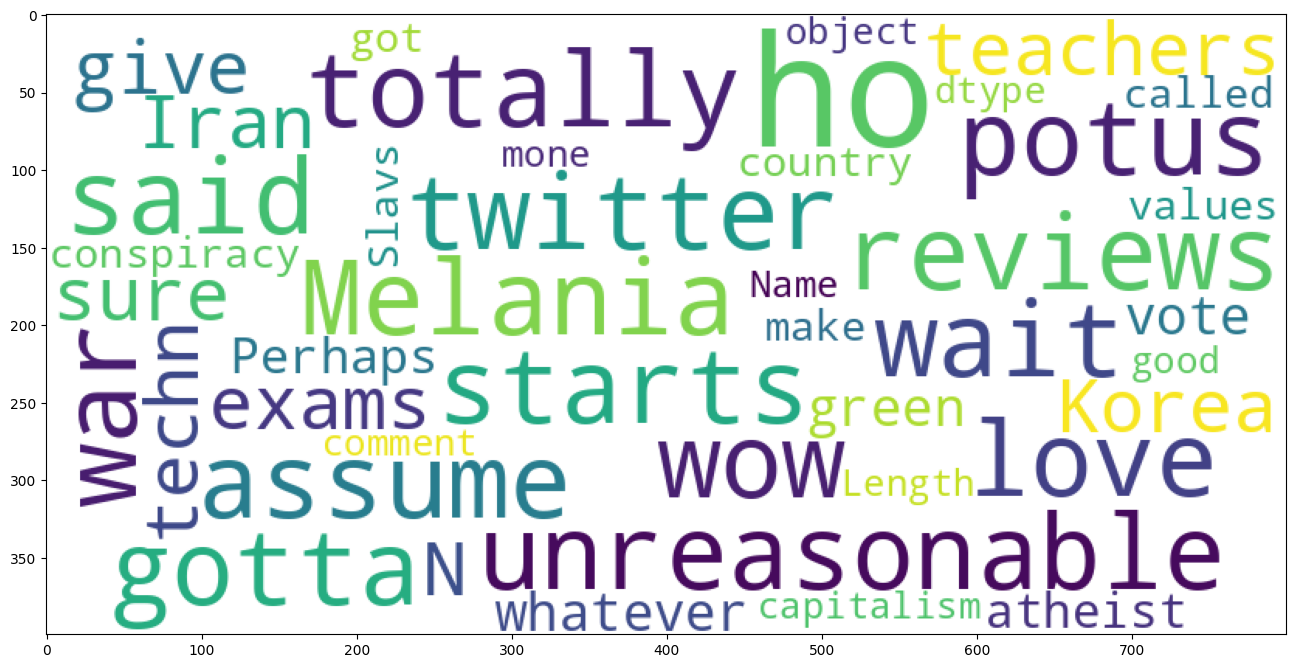

In [13]:
# most common words in comments with "sarcastic" label.
plt.figure(figsize=(16, 12))
wordcloud.generate(str(train_df.loc[train_df['label'] == 1, 'comment']))
plt.imshow(wordcloud);

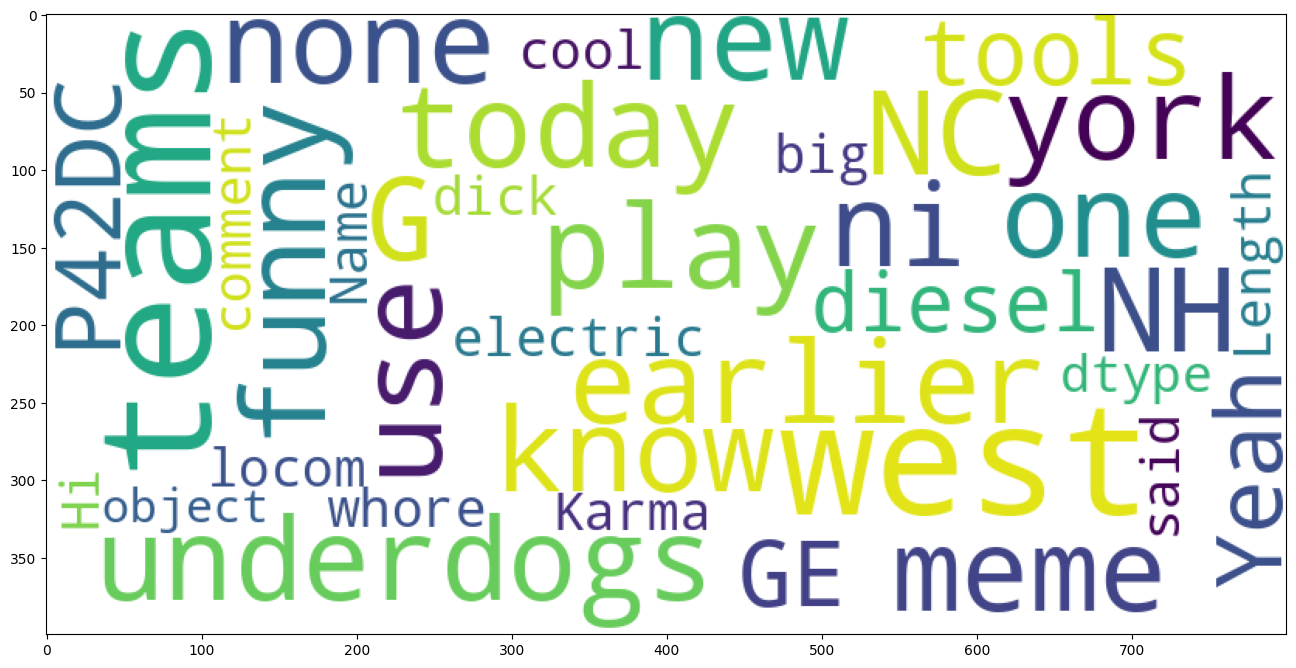

In [14]:
# most common words in comments with "not-sarcastic" label.
plt.figure(figsize=(16, 12))
wordcloud.generate(str(train_df.loc[train_df['label'] == 0, 'comment']))
plt.imshow(wordcloud);

In [15]:
sub_df = train_df.groupby('subreddit')['label'].agg([np.size, np.mean, np.sum])
sub_df.sort_values(by='sum', ascending=False).head(10)

/tmp/ipykernel_17/691556799.py:1: FutureWarning: The provided callable <function mean at 0x7fcae038d1c0> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  sub_df = train_df.groupby('subreddit')['label'].agg([np.size, np.mean, np.sum])
/tmp/ipykernel_17/691556799.py:1: FutureWarning: The provided callable <function sum at 0x7fcae038c0e0> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  sub_df = train_df.groupby('subreddit')['label'].agg([np.size, np.mean, np.sum])


,size,mean,sum
subreddit,,,
AskReddit,65674,0.401453,26365
politics,39493,0.605348,23907
worldnews,26375,0.642540,16947
leagueoflegends,21034,0.542312,11407
pcmasterrace,18987,0.566651,10759
news,16891,0.603457,10193
funny,17939,0.451474,8099
pics,16152,0.484336,7823
todayilearned,14159,0.547567,7753


In [16]:
from sklearn.feature_extraction.text import CountVectorizer

def get_top_ngrams(corpus, n=2, limit=20):
    # n=2 means "look for pairs of words" 
    vec = CountVectorizer(ngram_range=(n, n)).fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0) 
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    return sorted(words_freq, key = lambda x: x[1], reverse=True)[:limit]

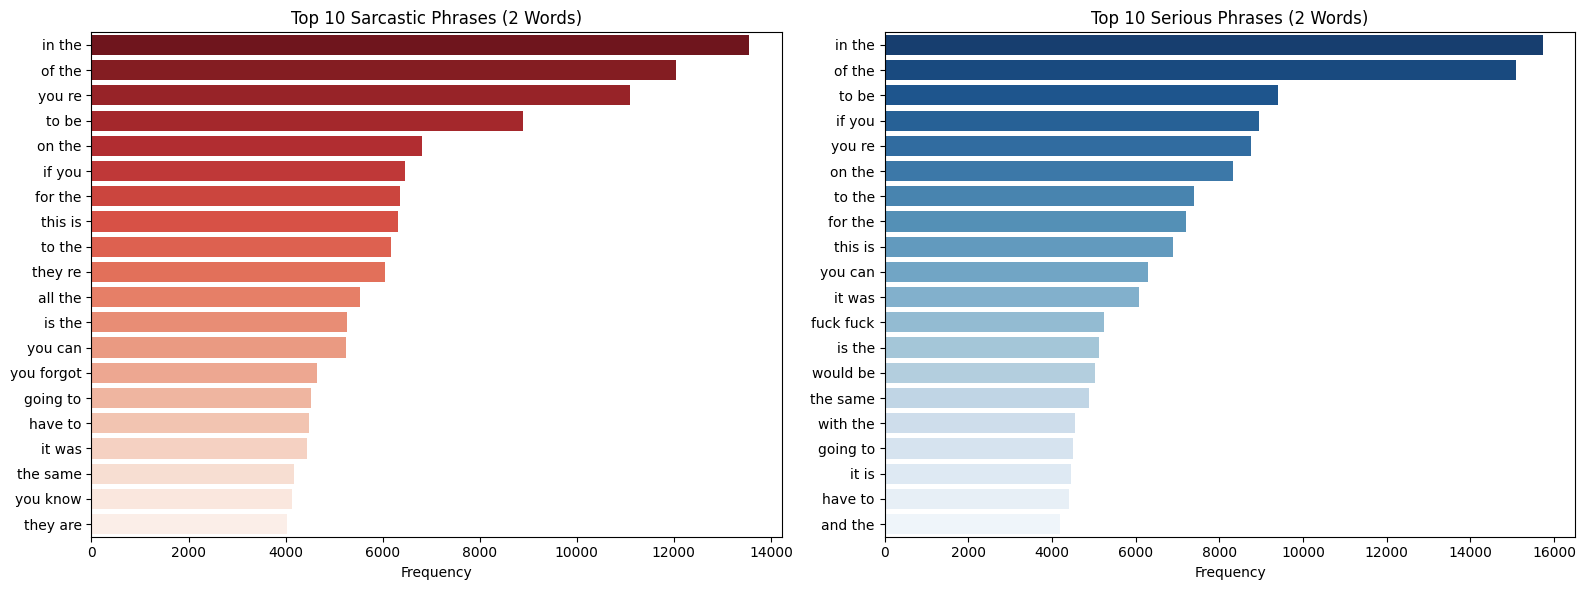

In [17]:
# Observing clean bi-grams 
top_bigrams_sarc = get_top_ngrams(train_df[train_df['label']==1]['comment'], n=2)
top_bigrams_ser = get_top_ngrams(train_df[train_df['label']==0]['comment'], n=2)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Sarcastic
x, y = zip(*top_bigrams_sarc)
sns.barplot(x=list(y), y=list(x), hue=list(x), palette='Reds_r', ax=axes[0], legend=False)
axes[0].set_title("Top 10 Sarcastic Phrases (2 Words)")
axes[0].set_xlabel("Frequency")

# Serious
x, y = zip(*top_bigrams_ser)
sns.barplot(x=list(y), y=list(x), hue=list(x), palette='Blues_r', ax=axes[1], legend=False)
axes[1].set_title("Top 10 Serious Phrases (2 Words)")
axes[1].set_xlabel("Frequency")

plt.tight_layout()
plt.show()

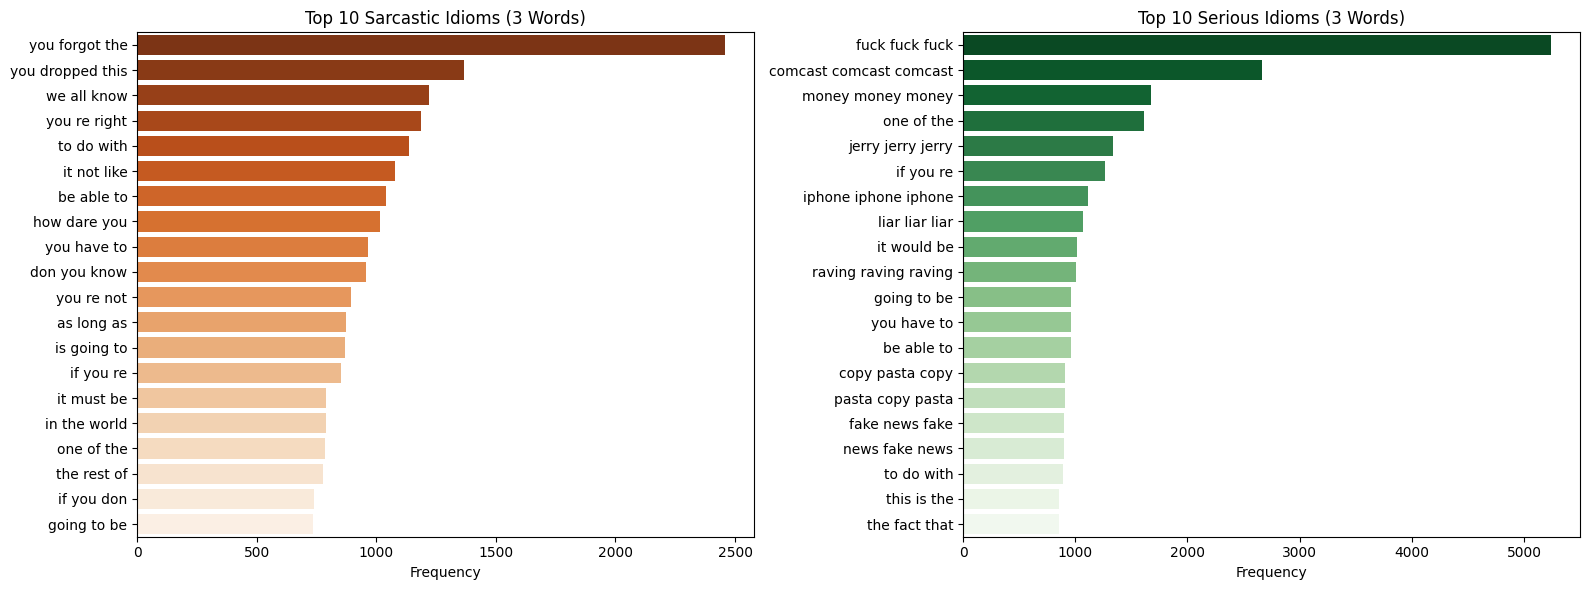

In [18]:
# Observing clean tri-grams
top_trigrams_sarc = get_top_ngrams(train_df[train_df['label']==1]['comment'], n=3)
top_trigrams_ser = get_top_ngrams(train_df[train_df['label']==0]['comment'], n=3)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Sarcastic
x, y = zip(*top_trigrams_sarc)
sns.barplot(x=list(y), y=list(x), hue=list(x), palette='Oranges_r', ax=axes[0], legend=False)
axes[0].set_title("Top 10 Sarcastic Idioms (3 Words)")
axes[0].set_xlabel("Frequency")

# Serious
x, y = zip(*top_trigrams_ser)
sns.barplot(x=list(y), y=list(x), hue=list(x), palette='Greens_r', ax=axes[1], legend=False)
axes[1].set_title("Top 10 Serious Idioms (3 Words)")
axes[1].set_xlabel("Frequency")

plt.tight_layout()
plt.show()

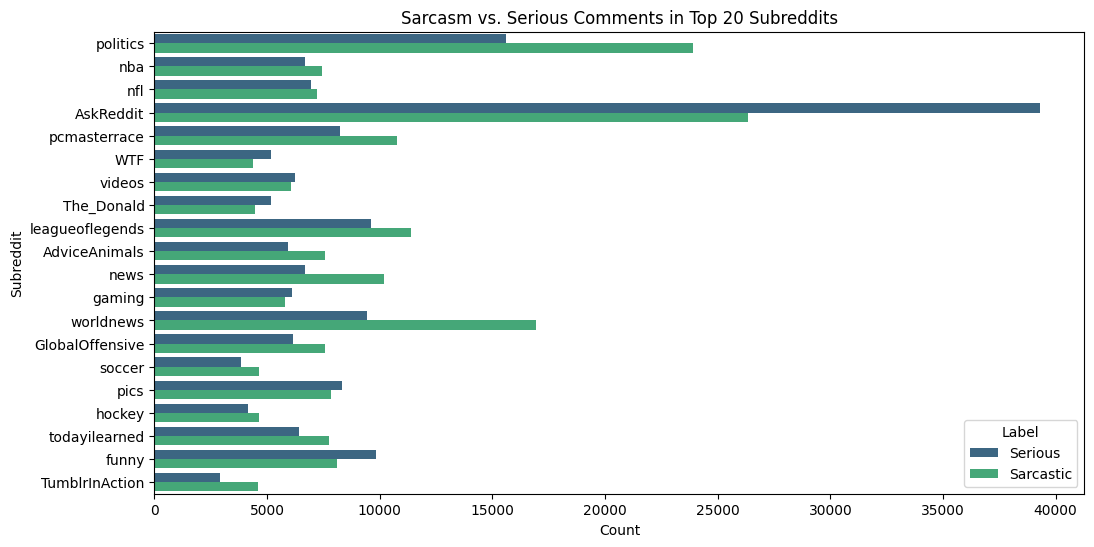

In [19]:
top_subs = train_df['subreddit'].value_counts().nlargest(20).index
sub_data = train_df[train_df['subreddit'].isin(top_subs)]

plt.figure(figsize=(12, 6))
sns.countplot(y='subreddit', hue='label', data=sub_data, palette='viridis')
plt.title('Sarcasm vs. Serious Comments in Top 20 Subreddits')
plt.xlabel('Count')
plt.ylabel('Subreddit')
plt.legend(title='Label', labels=['Serious', 'Sarcastic'])
plt.show()

In [20]:
def load_glove_index(file_path):
    """Loads GloVe vectors into a dictionary."""
    embeddings_index = {}
    with open(file_path, 'r', encoding='utf8') as f:
        for line in f:
            values = line.rstrip().split(' ')
            word = values[0]
            coefs = np.asarray(values[1:], dtype='float32')
            embeddings_index[word] = coefs
    return embeddings_index

In [21]:
glove_path = '/kaggle/input/datasets/sahilakolte/nlp-sarcasm-detection/glove.6B.300d.txt'
embeddings_dict = load_glove_index(glove_path)

In [22]:
import re

def tokenize(text):
    return re.findall(r"\w+|[^\w\s]", str(text).lower())

In [23]:
# from tqdm import tqdm
# tqdm.pandas() # Allows you to use .progress_apply()

# def vectorize_fast(df, embeddings_index, dimension=200):
#     def get_mean(text):
#         # Using a list comprehension is faster than multiple method calls
#         words = str(text).lower().split()
#         vectors = [embeddings_index[w] for w in words if w in embeddings_index]
#         return np.mean(vectors, axis=0) if vectors else np.zeros(dimension)

#     # progress_apply shows a progress bar for that 1M row loop
#     df['embedding'] = df['comment'].progress_apply(get_mean)

# # X_train = vectorize_fast(df_train, embeddings_dict)

In [24]:
from tqdm import tqdm
tqdm.pandas()

In [25]:
missing_words = set()

def vectorize_fast(df, embeddings_index, dimension=300):
    def get_mean(text):
        words = tokenize(text)
        
        found = []
        for w in words:
            if w in embeddings_index:
                found.append(embeddings_index[w])
            else:
                missing_words.add(w)  # track missing
        
        return np.mean(found, axis=0) if found else np.zeros(dimension)

    df['embedding'] = df['comment'].progress_apply(get_mean)

In [26]:
vectorize_fast(train_texts, embeddings_dict)

100%|██████████| 758078/758078 [00:38<00:00, 19710.00it/s]


In [27]:
vectorize_fast(valid_texts, embeddings_dict)

100%|██████████| 252693/252693 [00:12<00:00, 20140.41it/s]


In [28]:
vectorize_fast(test_df, embeddings_dict)

100%|██████████| 251608/251608 [00:13<00:00, 19290.34it/s]


In [29]:
print(len(missing_words))

74727


In [30]:
print(list(missing_words)[:1000])

['voaters', '7bfrffn5myj', 'diddums', 'kickem', 'vrworks', 'freedomchondria', 'saughter', 'odb_bza', 'antiescapism', 'fs2_open', 'yaaaaaaaaaaaasss', 'rytlock', 'thinkprogressive', 'dronie', 'winterboard', 'poweeerrr', 'boomtower', 'pekhota', 'crimethink', 'caeldori', 'kopidor', 'fudgin', 'bw1', 'wharrgarbl', '999999999', 'blizaard', 'pemprov', 'egokick', 'infin', '12us', 'o_o', 'bwahaha', 'aggys', 'riotbestcumpany', 'hastags', 'minoritays', '200bhp', 'donnys', 'hosnian', 'ndad', 'superincumbent', 'khoklachev', 'nmsflashbacks', 'spectulating', 'bashicly', 'posthardcore', '2400lb', 'gnignah', 'goalchances', 'worldnews', 'rayydeon', '185mm', 'downtm', 'd4nny', 'shouldtry', 'critted', 'scottlee', 'tomatocarrotjuice', 'bazaakaaaa', 'scottcawthon744', 'tards', 'foxys', 'pandiistarcraft', 'grafex', 'savingtheworld', 'lloydehtbh', 'balzerian', 'ephialties', 'sunsource', '1400mhz', 'youshitsfm', 'winkyface', 'hyaaaaaaaah', 'dickbags', 'bruther', 'achamian', 'wglna', 'seaparks', 'neckin', 'jaxxs

In [31]:
zero_rows = train_texts[train_texts['embedding'].apply(lambda x: np.all(x == 0))]
print(len(zero_rows))
# Show first few
zero_rows.head()

2789


,label,comment,author,subreddit,score,ups,downs,date,created_utc,parent_comment,embedding
351261,1,OVERRATEDSON,RaylanCrowder,Cricket,19,19,0,2016-05,1464630910,Jimmy's current series in perspective.,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
986652,0,T_T,Nivardica,funny,1,1,0,2012-11,1352078953,DO NOT WANT!,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
453649,0,Lmao,HLDLonghorn,fantasyfootball,3,3,0,2015-11,1448554527,I'm thankful Smokey Brown didn't smash my girl...,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
951303,0,HAHAHAHAHHHAHAHAHA,whoopashigitt,leagueoflegends,37,37,0,2013-10,1382730481,syndra. Cant dodge this one bitch!,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
167071,0,Colorizebot,SmileyFaceInk,BikiniBottomTwitter,3,3,0,2016-09,1472811708,German experiments in concentration camps,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."


In [32]:
train_texts = train_texts[~train_texts['embedding'].apply(lambda x: np.all(x == 0))]

In [33]:
train_texts.head()

,label,comment,author,subreddit,score,ups,downs,date,created_utc,parent_comment,embedding
190606,0,and paired up with a team of potatoes.,kingal0ha,blackops3,5,5,0,2016-07,1469641396,Seems easy but I know I will be put up against...,"[-0.1797929, -0.07167089, 0.18451665, 0.077747..."
169436,0,"""Drift and Die"", as well.",antillian,Music,0,-1,-1,2016-10,1476491356,She Hates Me (make sure its the unedited versi...,"[-0.3996358, -0.26716855, 0.20481867, -0.09291..."
771949,1,"Thanks, he must be the guy everyone has in the...",ImS0hungry,AirForce,-3,-3,0,2014-12,1418506180,Obviously this is a situation where OP could g...,"[-0.061458617, 0.034962434, 0.121088944, -0.03..."
675529,0,Added to original post,d72x,beermoney,4,4,0,2015-04,1428255640,That is ridiculous but proof?,"[-0.2604595, 0.2054515, 0.21669227, -0.0435355..."
823896,0,"If it makes you feel better, these aren't real...",easterplatypus,Guildwars2,4,4,0,2014-01,1389715645,""" minipet slot added"" ""reduced ammount of silk...","[-0.20251776, 0.075375125, 0.23840822, 0.05507..."


In [34]:
# 1. Drop any rows where the embedding might be missing
train_texts = train_texts.dropna(subset=['embedding'])

# 2. Safety check: Ensure all embeddings are arrays of the same length
# (In case some rows returned a single float instead of a vector)
train_texts = train_texts[train_texts['embedding'].map(lambda x: isinstance(x, np.ndarray))]

In [35]:
X = np.stack(train_texts['embedding'].values)
y = train_texts['label'].values

In [36]:
valid_texts['embedding'].apply(lambda x: np.shape(x)).value_counts()

embedding
(300,)    252693
Name: count, dtype: int64

In [37]:
X_valid = np.stack(valid_texts['embedding'].values)
y_valid = valid_texts['label'].values

In [38]:
print(X[:10])

[[-0.1797929  -0.07167089  0.18451665 ...  0.02497567 -0.13325045
  -0.04411656]
 [-0.3996358  -0.26716855  0.20481867 ... -0.00305733 -0.06783699
  -0.15788276]
 [-0.06145862  0.03496243  0.12108894 ... -0.06270924  0.10312991
   0.09936276]
 ...
 [-0.08705176 -0.03017685  0.2232356  ...  0.06824469  0.09132001
  -0.10396247]
 [-0.07234824  0.02388634  0.24839409 ... -0.11959692  0.09219509
  -0.06389958]
 [-0.11524718  0.04712936  0.2105852  ... -0.08551728  0.18680967
  -0.03417532]]


In [39]:
print(X_valid[:10])

[[-0.27334842 -0.13731484  0.05546643 ...  0.16952486  0.11681128
   0.08852843]
 [-0.15986019 -0.01080819  0.0432014  ... -0.01573592 -0.08425579
  -0.00673368]
 [-0.1594609   0.02936391  0.26849452 ... -0.08691529  0.0016876
  -0.19177151]
 ...
 [-0.25968945 -0.08031979  0.09167754 ... -0.24993558  0.0035711
  -0.07521144]
 [-0.25801745 -0.10808618  0.05282082 ... -0.01357018 -0.15162045
  -0.11633527]
 [-0.23294701 -0.039866    0.22511899 ... -0.115015   -0.213442
  -0.409242  ]]


In [40]:
# Double check the shape - should be (Rows, 300)
print(f"Feature matrix shape: {X.shape}")

Feature matrix shape: (755289, 300)


In [41]:
# 3. Initialize and train Logistic Regression
# 'saga' is faster for 1M+ samples; 'max_iter' ensures convergence
logit = LogisticRegression(solver='saga', max_iter=1000, C=1.0, n_jobs=-1, random_state=42, verbose=2)
logit.fit(X, y)

# 4. Generate predictions
y_pred = logit.predict(X_valid)
y_score = logit.predict_proba(X_valid)[:, 1] # Probabilities for ROC curve

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 4 concurrent workers.


convergence after 16 epochs took 90 seconds


In [42]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

In [43]:
print("--- Classification Report ---")
print(classification_report(y_valid, y_pred, target_names=['Not Sarcastic', 'Sarcastic']))
# print("--- Classification Report(Train) ---")
# print(classification_report(y_valid, y_pred, target_names=['Not Sarcastic', 'Sarcastic']))

--- Classification Report ---
               precision    recall  f1-score   support

Not Sarcastic       0.63      0.61      0.62    126226
    Sarcastic       0.62      0.63      0.63    126467

     accuracy                           0.62    252693
    macro avg       0.62      0.62      0.62    252693
 weighted avg       0.62      0.62      0.62    252693



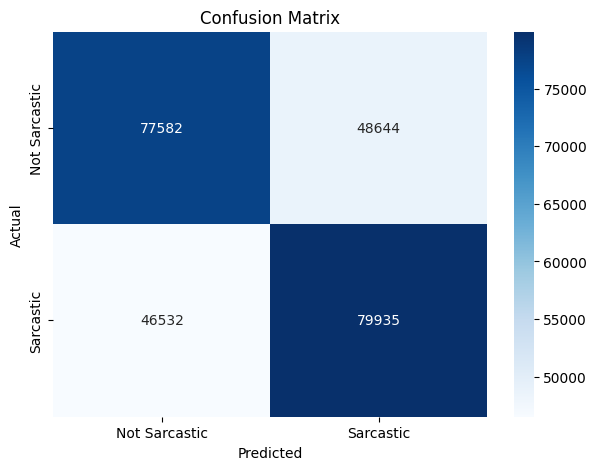

In [44]:
def plot_confusion_matrix(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Not Sarcastic', 'Sarcastic'], 
                yticklabels=['Not Sarcastic', 'Sarcastic'])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.show()

plot_confusion_matrix(y_valid, y_pred)

In [45]:
from sklearn.metrics import roc_curve, auc

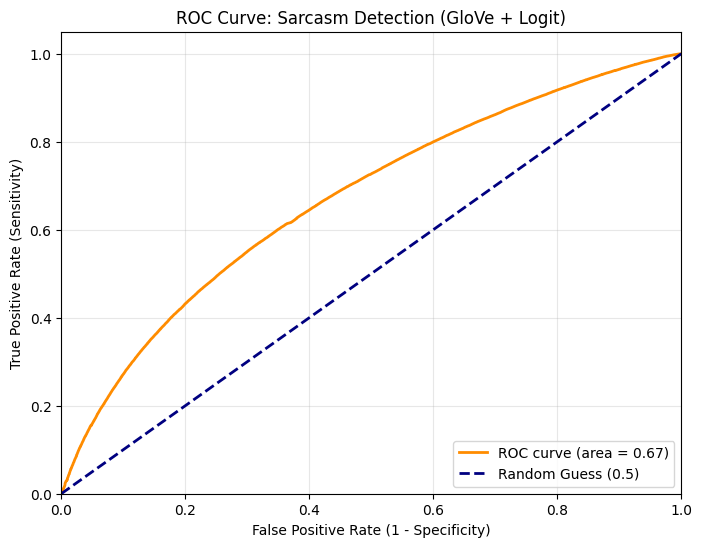

Final AUC Score: 0.6700


In [46]:
def plot_roc_curve(y_true, y_score):
    fpr, tpr, thresholds = roc_curve(y_true, y_score)
    roc_auc = auc(fpr, tpr)
    
    # 2. Plot the ROC Curve
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
    
    # Plot the "Random Guess" diagonal line
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guess (0.5)')
    
    # Formatting the plot
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate (1 - Specificity)')
    plt.ylabel('True Positive Rate (Sensitivity)')
    plt.title('ROC Curve: Sarcasm Detection (GloVe + Logit)')
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.show()
    
    print(f"Final AUC Score: {roc_auc:.4f}")

plot_roc_curve(y_valid, y_score)

In [47]:
accuracy_score(y_valid, y_pred)

0.6233532389104566

In [48]:
import pickle

# Save
with open('sarcasm_model.pkl', 'wb') as f:
    pickle.dump(logit, f)

In [49]:
X_test = np.stack(test_df['embedding'].values)
y_test = test_df['label'].values

In [50]:
y_pred = logit.predict(X_valid)
y_score = logit.predict_proba(X_valid)[:, 1] 

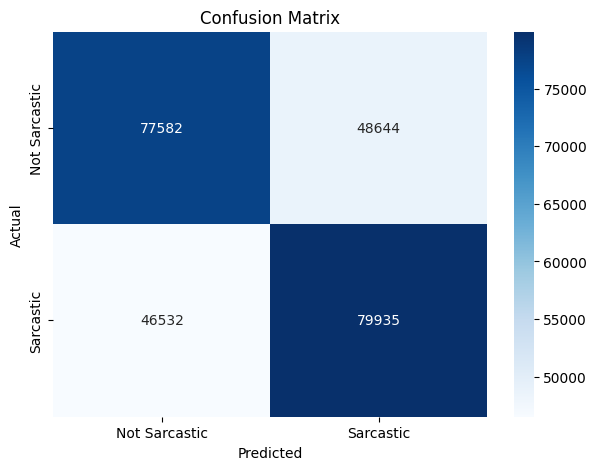

In [51]:
plot_confusion_matrix(y_valid, y_pred)

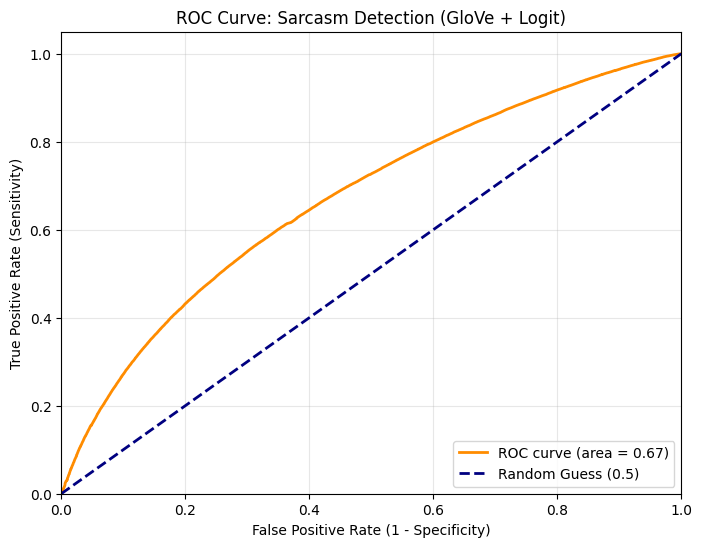

Final AUC Score: 0.6700


In [52]:
plot_roc_curve(y_valid, y_score)

In [53]:
print("Classification Report(TEST)")
print(classification_report(y_valid, y_pred, target_names=['Not Sarcastic', 'Sarcastic']))

Classification Report(TEST)
               precision    recall  f1-score   support

Not Sarcastic       0.63      0.61      0.62    126226
    Sarcastic       0.62      0.63      0.63    126467

     accuracy                           0.62    252693
    macro avg       0.62      0.62      0.62    252693
 weighted avg       0.62      0.62      0.62    252693



In [54]:
accuracy_score(y_valid, y_pred)

0.6233532389104566